<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/Desbalanceo_de_Datos_Oversampling_y_Smote.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should


🚀 Generando dataset desbalanceado...

Distribución Original:
[859 141]

Distribución Oversampling:
[859 859]

Distribución SMOTE:
[859 859]


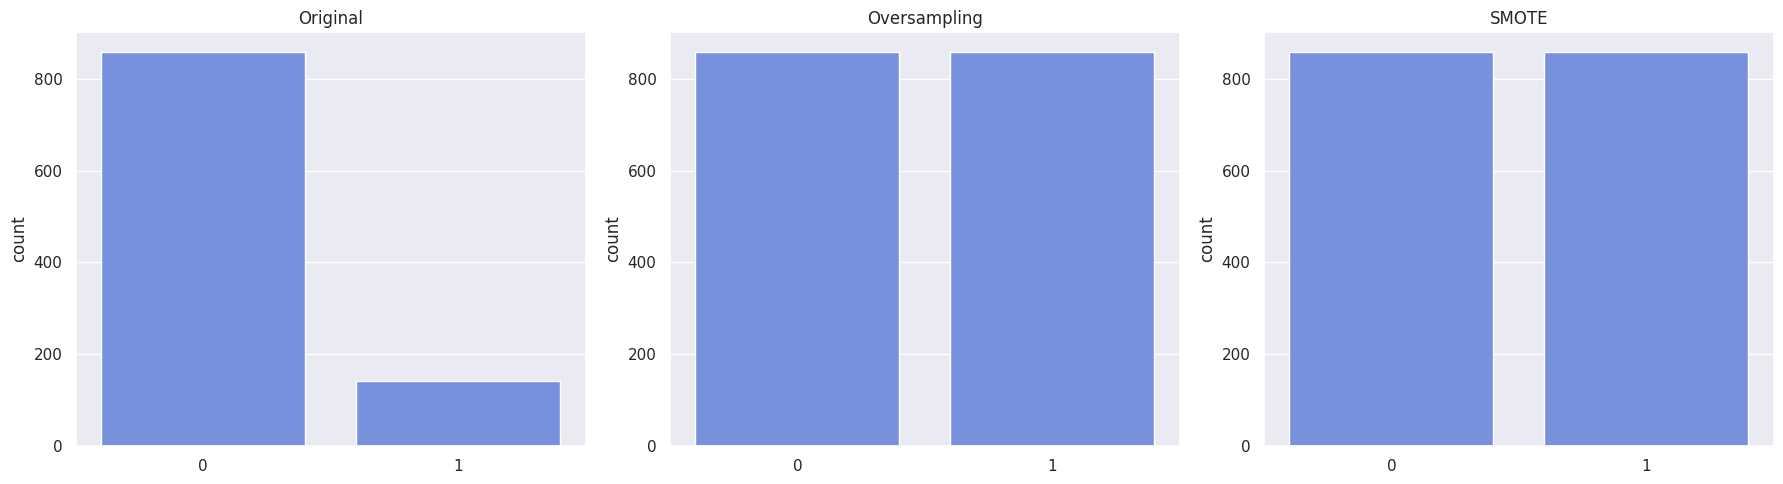

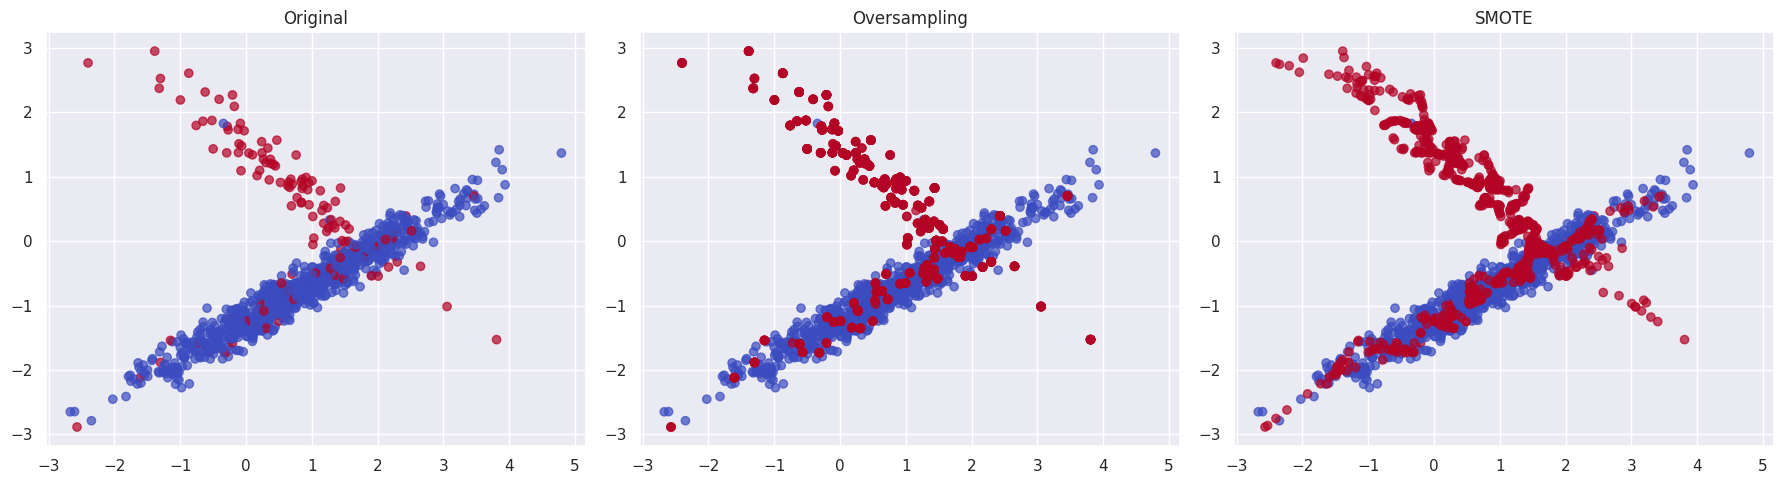


ORIGINAL
Accuracy : 0.935
Recall   : 0.553
F1 Score : 0.706

Reporte:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       859
           1       0.97      0.55      0.71       141

    accuracy                           0.94      1000
   macro avg       0.95      0.78      0.83      1000
weighted avg       0.94      0.94      0.93      1000


OVERSAMPLING
Accuracy : 0.820
Recall   : 0.696
F1 Score : 0.794

Reporte:
              precision    recall  f1-score   support

           0       0.76      0.94      0.84       859
           1       0.92      0.70      0.79       859

    accuracy                           0.82      1718
   macro avg       0.84      0.82      0.82      1718
weighted avg       0.84      0.82      0.82      1718


SMOTE
Accuracy : 0.806
Recall   : 0.636
F1 Score : 0.766

Reporte:
              precision    recall  f1-score   support

           0       0.73      0.98      0.83       859
           1       0.96

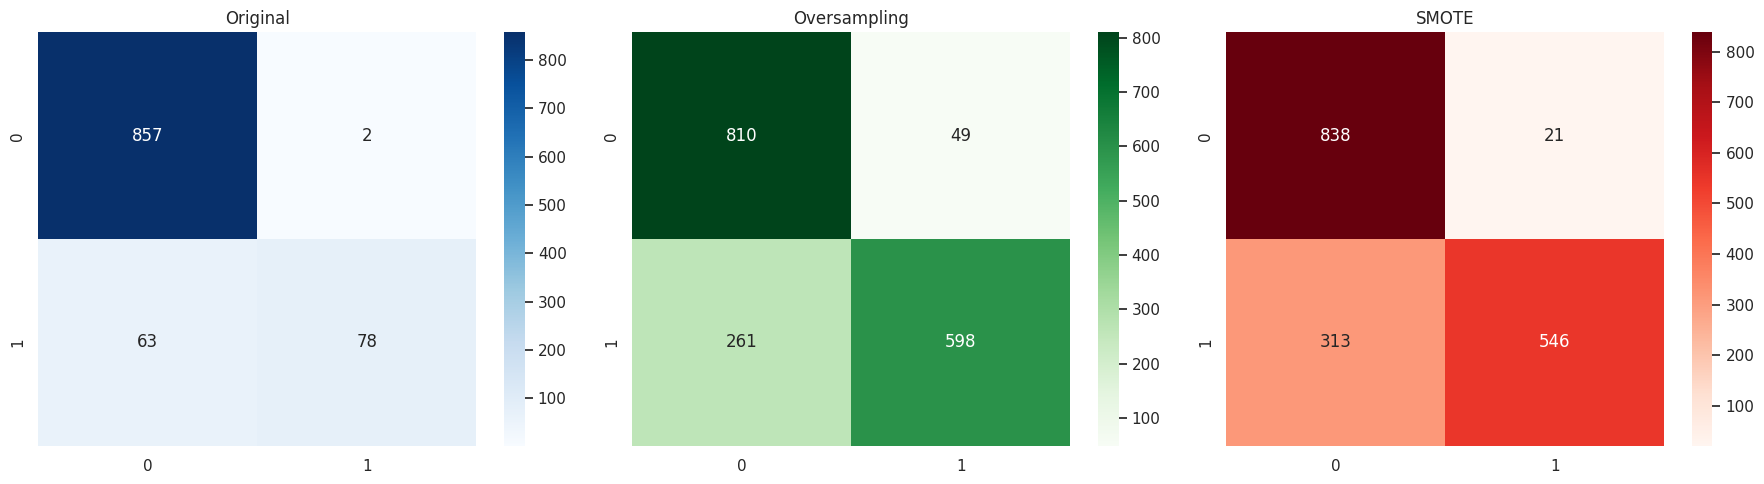

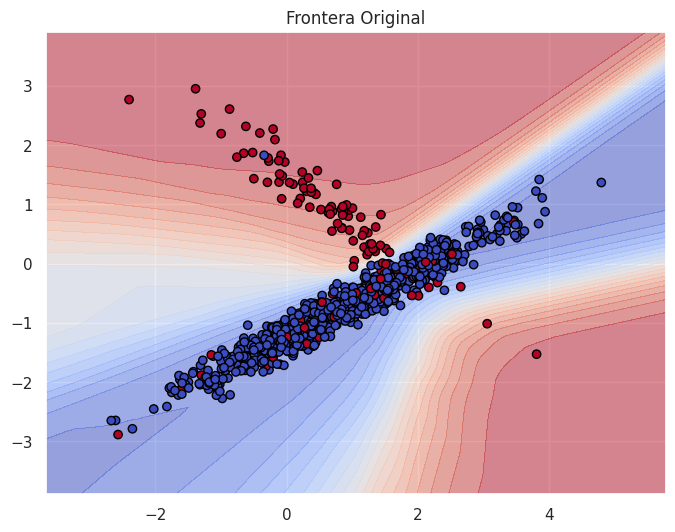

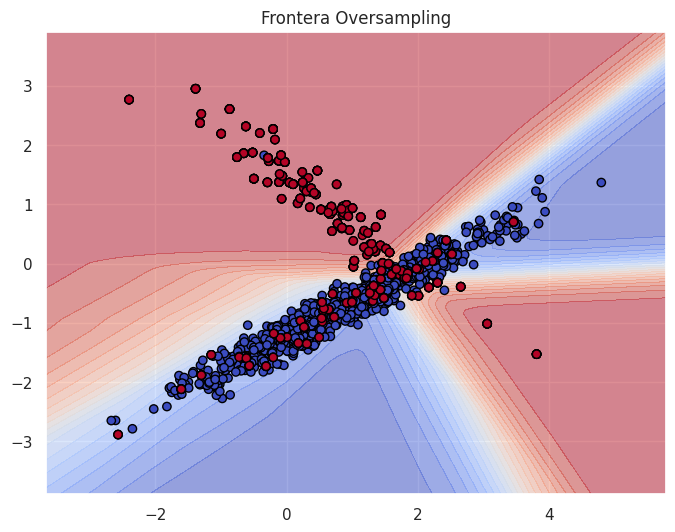

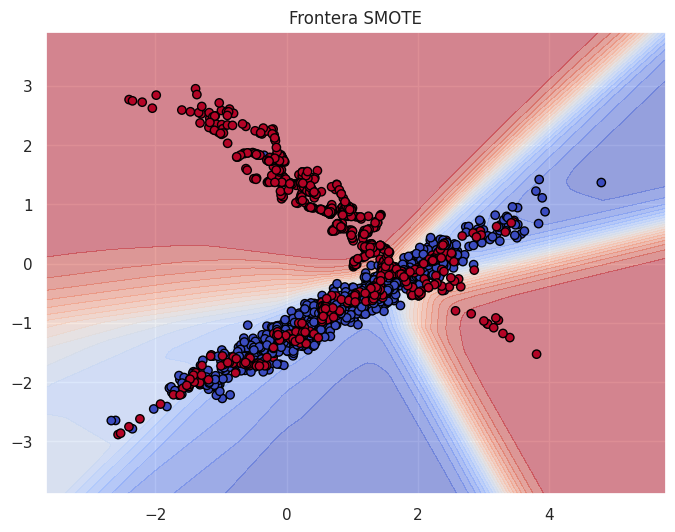

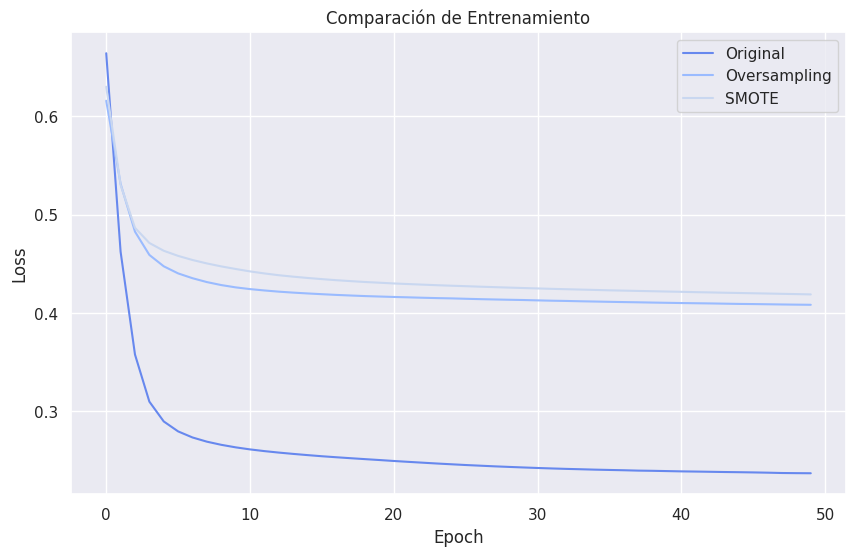


✅ Experimento terminado


In [3]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score,
    recall_score
)

from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

# ==========================================================
# CONFIGURACIÓN VISUAL
# ==========================================================

sns.set_theme(style="darkgrid", palette="coolwarm")

COLOR_CLASE0 = "#1E88E5"
COLOR_CLASE1 = "#F4511E"

np.random.seed(42)
tf.random.set_seed(42)


# CREAR DATOS DESBALANCEADOS
print("\n🚀 Generando dataset desbalanceado...")

X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    weights=[0.90, 0.10],
    flip_y=0.10,
    class_sep=0.8,
    random_state=42
)

print("\nDistribución Original:")
print(np.bincount(y))

# OVERSAMPLING

X_major = X[y == 0]
X_minor = X[y == 1]

y_major = y[y == 0]
y_minor = y[y == 1]

X_minor_up, y_minor_up = resample(
    X_minor,
    y_minor,
    replace=True,
    n_samples=len(X_major),
    random_state=42
)

X_over = np.vstack([X_major, X_minor_up])
y_over = np.hstack([y_major, y_minor_up])

print("\nDistribución Oversampling:")
print(np.bincount(y_over))

# ==========================================================
# SMOTE
# ==========================================================

smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(X, y)

print("\nDistribución SMOTE:")
print(np.bincount(y_smote))

# ==========================================================
# VISUALIZAR DISTRIBUCIÓN DE CLASES
# ==========================================================

fig, ax = plt.subplots(1,3, figsize=(18,5))

sns.countplot(x=y, ax=ax[0])
ax[0].set_title("Original")

sns.countplot(x=y_over, ax=ax[1])
ax[1].set_title("Oversampling")

sns.countplot(x=y_smote, ax=ax[2])
ax[2].set_title("SMOTE")

plt.tight_layout()
plt.show()

# ==========================================================
# SCATTER PLOTS
# ==========================================================

fig, ax = plt.subplots(1,3, figsize=(18,5))

ax[0].scatter(
    X[:,0],
    X[:,1],
    c=y,
    cmap="coolwarm",
    alpha=0.7
)
ax[0].set_title("Original")

ax[1].scatter(
    X_over[:,0],
    X_over[:,1],
    c=y_over,
    cmap="coolwarm",
    alpha=0.7
)
ax[1].set_title("Oversampling")

ax[2].scatter(
    X_smote[:,0],
    X_smote[:,1],
    c=y_smote,
    cmap="coolwarm",
    alpha=0.7
)
ax[2].set_title("SMOTE")

plt.tight_layout()
plt.show()

# ==========================================================
# FUNCIÓN PARA CREAR MODELO
# ==========================================================

def crear_modelo():

    model = tf.keras.Sequential([

        tf.keras.layers.Input(shape=(2,)),

        tf.keras.layers.Dense(
            32,
            activation='relu'
        ),

        tf.keras.layers.Dense(
            32,
            activation='relu'
        ),

        tf.keras.layers.Dense(
            1,
            activation='sigmoid'
        )

    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# ==========================================================
# ENTRENAR Y EVALUAR
# ==========================================================

def entrenar(nombre, X_data, y_data):

    print("\n" + "="*50)
    print(nombre)
    print("="*50)

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X_data)

    model = crear_modelo()

    history = model.fit(
        X_scaled,
        y_data,
        epochs=50,
        batch_size=32,
        verbose=0
    )

    pred = (
        model.predict(
            X_scaled,
            verbose=0
        ) > 0.5
    ).astype(int)

    acc = accuracy_score(y_data, pred)
    rec = recall_score(y_data, pred)
    f1 = f1_score(y_data, pred)

    print(f"Accuracy : {acc:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"F1 Score : {f1:.3f}")

    print("\nReporte:")
    print(classification_report(y_data, pred))

    return model, scaler, history, pred

# ==========================================================
# ENTRENAMIENTO
# ==========================================================

model_original, scaler_original, hist_original, pred_original = entrenar(
    "ORIGINAL",
    X,
    y
)

model_over, scaler_over, hist_over, pred_over = entrenar(
    "OVERSAMPLING",
    X_over,
    y_over
)

model_smote, scaler_smote, hist_smote, pred_smote = entrenar(
    "SMOTE",
    X_smote,
    y_smote
)

# ==========================================================
# MATRICES DE CONFUSIÓN
# ==========================================================

fig, ax = plt.subplots(1,3, figsize=(18,5))

cm = confusion_matrix(y, pred_original)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax[0]
)

ax[0].set_title("Original")

cm = confusion_matrix(y_over, pred_over)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=ax[1]
)

ax[1].set_title("Oversampling")

cm = confusion_matrix(y_smote, pred_smote)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    ax=ax[2]
)

ax[2].set_title("SMOTE")

plt.tight_layout()
plt.show()

# ==========================================================
# FRONTERA DE DECISIÓN
# ==========================================================

def frontera_decision(
    model,
    scaler,
    X,
    y,
    titulo
):

    x_min = X[:,0].min() - 1
    x_max = X[:,0].max() + 1

    y_min = X[:,1].min() - 1
    y_max = X[:,1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.05),
        np.arange(y_min, y_max, 0.05)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    grid_scaled = scaler.transform(grid)

    Z = model.predict(
        grid_scaled,
        verbose=0
    )

    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8,6))

    plt.contourf(
        xx,
        yy,
        Z,
        levels=20,
        cmap='coolwarm',
        alpha=0.5
    )

    plt.scatter(
        X[:,0],
        X[:,1],
        c=y,
        cmap='coolwarm',
        edgecolors='black'
    )

    plt.title(titulo)

    plt.show()

# ==========================================================
# FRONTERAS
# ==========================================================

frontera_decision(
    model_original,
    scaler_original,
    X,
    y,
    "Frontera Original"
)

frontera_decision(
    model_over,
    scaler_over,
    X_over,
    y_over,
    "Frontera Oversampling"
)

frontera_decision(
    model_smote,
    scaler_smote,
    X_smote,
    y_smote,
    "Frontera SMOTE"
)

# ==========================================================
# CURVAS DE APRENDIZAJE
# ==========================================================

plt.figure(figsize=(10,6))

plt.plot(
    hist_original.history['loss'],
    label='Original'
)

plt.plot(
    hist_over.history['loss'],
    label='Oversampling'
)

plt.plot(
    hist_smote.history['loss'],
    label='SMOTE'
)

plt.title("Comparación de Entrenamiento")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

print("\n✅ Experimento terminado")

In [2]:
!sudo apt update
!sudo apt install libcairo2-dev ffmpeg libpango1.0-dev freeglut3-dev mesa-utils lmodern
!pip install manim

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://cli.github.com/packages stable InRelease [3,917 B]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,303 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [4,006 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,183 kB]
Get:13 https://cli.github.com/packages stable/main amd64 Packages [355 B

In [1]:
%load_ext manim

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


The manim module is not an IPython extension.


In [2]:
%%manim -qm -v WARNING DesbalanceoDatos

from manim import *
import numpy as np

class DesbalanceoDatos(Scene):
    def construct(self):

        # --------------------------------------------------
        # TÍTULO
        # --------------------------------------------------

        titulo = Text(
            "¿Qué es el Desbalanceo de Datos?",
            font_size=42
        )

        subtitulo = Text(
            "El problema invisible en Machine Learning",
            font_size=24,
            color=YELLOW
        )

        subtitulo.next_to(titulo, DOWN)

        self.play(Write(titulo))
        self.play(FadeIn(subtitulo))
        self.wait(2)

        self.play(
            FadeOut(titulo),
            FadeOut(subtitulo)
        )

        # --------------------------------------------------
        # EJE DE DISPERSIÓN
        # --------------------------------------------------

        plano = NumberPlane(
            x_range=[0,10],
            y_range=[0,10],
            background_line_style={
                "stroke_opacity":0.3
            }
        ).scale(0.7)

        self.play(Create(plano))

        # --------------------------------------------------
        # GENERAR DATOS
        # --------------------------------------------------

        np.random.seed(42)

        puntos_azules = VGroup()
        puntos_rojos = VGroup()

        # 90 puntos azules
        for _ in range(90):

            x = np.random.normal(4, 1.2)
            y = np.random.normal(5, 1.5)

            punto = Dot(
                plano.c2p(x, y),
                color=BLUE,
                radius=0.05
            )

            puntos_azules.add(punto)

        # 10 puntos rojos
        for _ in range(10):

            x = np.random.normal(7, 1)
            y = np.random.normal(6, 1)

            punto = Dot(
                plano.c2p(x, y),
                color=RED,
                radius=0.06
            )

            puntos_rojos.add(punto)

        # --------------------------------------------------
        # APARECEN LOS DATOS
        # --------------------------------------------------

        texto1 = Text(
            "90% Clase Mayoritaria",
            color=BLUE,
            font_size=30
        ).to_edge(LEFT)

        texto2 = Text(
            "10% Clase Minoritaria",
            color=RED,
            font_size=30
        ).to_edge(RIGHT)

        self.play(Write(texto1))

        self.play(
            LaggedStart(
                *[FadeIn(p) for p in puntos_azules],
                lag_ratio=0.02,
                run_time=2
            )
        )

        self.wait(1)

        self.play(Write(texto2))

        self.play(
            LaggedStart(
                *[FadeIn(p) for p in puntos_rojos],
                lag_ratio=0.08,
                run_time=2
            )
        )

        self.wait(2)

        # --------------------------------------------------
        # MENSAJE DE ALERTA
        # --------------------------------------------------

        alerta = Text(
            "La IA aprenderá más de los datos azules",
            color=YELLOW,
            font_size=32
        )

        alerta.to_edge(DOWN)

        self.play(
            Write(alerta)
        )

        self.wait(3)

        # --------------------------------------------------
        # RESALTAR DESBALANCE
        # --------------------------------------------------

        circulo = Circle(
            color=RED,
            stroke_width=6
        ).scale(1.2)

        circulo.move_to(
            puntos_rojos.get_center()
        )

        self.play(
            Create(circulo)
        )

        explicacion = Text(
            "Muy pocos ejemplos",
            color=RED,
            font_size=28
        )

        explicacion.next_to(circulo, UP)

        self.play(
            Write(explicacion)
        )

        self.wait(3)

Manim Community v0.20.1